# 滑块验证码缺口检测与互动演示

这个笔记本演示了如何识别滑块验证码中的缺口，并提供了一个交互式的前端界面。

In [22]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from google.colab.patches import cv2_imshow
import base64

def create_captcha_demo():
    # 1. 创建随机彩色背景
    bg = np.zeros((200, 400, 3), dtype=np.uint8)
    bg[:] = np.random.randint(200, 255, size=(3,), dtype=np.uint8) # 随机浅色底

    # 添加随机干扰几何图形
    for _ in range(15):
        color = np.random.randint(100, 200, size=(3,)).tolist()
        x1, y1 = np.random.randint(0, 400), np.random.randint(0, 200)
        size = np.random.randint(10, 50)
        if np.random.rand() > 0.5:
            cv2.circle(bg, (x1, y1), size, color, -1)
        else:
            cv2.rectangle(bg, (x1, y1), (x1+size, y1+size), color, -1)

    # 2. 随机生成缺口位置
    gap_size = 40
    gap_x = np.random.randint(150, 350)
    gap_y = np.random.randint(20, 140)

    # 3. 准备图像
    target_img = bg.copy()
    # 提取滑块内容
    slider_img = bg[gap_y:gap_y+gap_size, gap_x:gap_x+gap_size].copy()
    # 给滑块加个边框感
    cv2.rectangle(slider_img, (0, 0), (gap_size-1, gap_size-1), (255, 255, 255), 1)

    # 在背景上绘制深色半透明遮罩作为“缺口”
    mask = target_img[gap_y:gap_y+gap_size, gap_x:gap_x+gap_size]
    dark_mask = cv2.addWeighted(mask, 0.3, np.zeros(mask.shape, mask.dtype), 0, 0)
    target_img[gap_y:gap_y+gap_size, gap_x:gap_x+gap_size] = dark_mask
    # 给背景缺口加个描边
    cv2.rectangle(target_img, (gap_x, gap_y), (gap_x + gap_size, gap_y + gap_size), (80, 80, 80), 1)

    return target_img, slider_img, gap_x, gap_y

# 重新生成图像
target, slider, real_x, real_y = create_captcha_demo()

# 检测逻辑
def detect_gap(target, slider):
    """
    使用 OpenCV 模板匹配识别滑块验证码缺口位置

    参数:
    target: 带有缺口的背景图像 (numpy array)
    slider: 抠出来的滑块图像 (numpy array)

    返回:
    predicted_x: 预测的缺口左上角 X 坐标
    """
    # 1. 转换为灰度图，减少颜色信息干扰，提高匹配效率
    target_gray = cv2.cvtColor(target, cv2.COLOR_BGR2GRAY)
    slider_gray = cv2.cvtColor(slider, cv2.COLOR_BGR2GRAY)

    # 2. 模板匹配
    # TM_SQDIFF_NORMED (归一化平方差匹配): 这种方法通过计算像素间亮度的差异来寻找目标
    # 由于背景缺口被我们处理成了深色（亮度低），它与原始滑块图的平方差会产生一个明显极值
    res = cv2.matchTemplate(target_gray, slider_gray, cv2.TM_SQDIFF_NORMED)

    # 3. 获取匹配结果中的最佳位置
    # 对于 SQDIFF 方法，数值越小代表匹配程度越高（差异越小）
    # min_loc 返回的就是结果矩阵中最小值所在的坐标 (x, y)
    min_val, max_val, min_loc, _ = cv2.minMaxLoc(res)

    # 返回匹配到的 X 轴偏移量
    return min_loc[0]

predicted_x = detect_gap(target, slider)

def img_to_base64(img):
    _, buffer = cv2.imencode('.png', img)
    return base64.b64encode(buffer).decode('utf-8')

target_base64 = img_to_base64(target)
slider_base64 = img_to_base64(slider)
print(f"新生成的缺口位置: x={real_x}, y={real_y}")

新生成的缺口位置: x=223, y=32



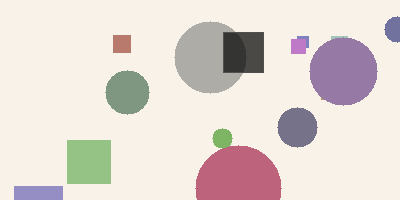
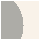

In [23]:
from IPython.display import HTML

# 构建前端互动 Demo
html_code = f"""
<div id="captcha-container" style="width: 400px; border: 1px solid #ccc; padding: 10px; user-select: none;">
    <div style="position: relative; width: 400px; height: 200px; overflow: hidden;">
        <img src="data:image/png;base64,{target_base64}" style="width: 400px; height: 200px;" />
        <div id="slider-block" style="position: absolute; left: 0px; top: {real_y}px; width: 40px; height: 40px; border: 2px solid #fff; box-shadow: 0 0 5px rgba(0,0,0,0.5);">
            <img src="data:image/png;base64,{slider_base64}" style="width: 40px; height: 40px;" />
        </div>
    </div>
    <div id="track" style="width: 100%; height: 20px; background: #eee; margin-top: 15px; position: relative; border-radius: 10px;">
        <div id="handle" style="width: 40px; height: 30px; background: #007bff; position: absolute; top: -5px; left: 0; cursor: pointer; border-radius: 5px; color: white; text-align: center; line-height: 30px; font-size: 12px;">>>></div>
    </div>
    <p id="status" style="margin-top: 10px; font-weight: bold;">拖动滑块验证</p>
</div>

<script>
(function() {{
    const handle = document.getElementById('handle');
    const slider = document.getElementById('slider-block');
    const track = document.getElementById('track');
    const status = document.getElementById('status');
    let isDragging = false;
    let startX = 0;
    const targetX = {real_x};
    const tolerance = 10; // 增加容错范围

    handle.onmousedown = function(e) {{
        isDragging = true;
        startX = e.clientX - handle.offsetLeft;
    }};

    document.onmousemove = function(e) {{
        if (!isDragging) return;
        let x = e.clientX - startX;
        if (x < 0) x = 0;
        if (x > 360) x = 360;
        handle.style.left = x + 'px';
        slider.style.left = x + 'px';
    }};

    document.onmouseup = function(e) {{
        if (!isDragging) return;
        isDragging = false;
        const currentX = parseInt(handle.style.left);
        if (Math.abs(currentX - targetX) <= tolerance) {{
            status.innerText = "验证通过！(预测误差: " + Math.abs(currentX - targetX) + "px)";
            status.style.color = "green";
            handle.style.background = "#28a745";
        }} else {{
            status.innerText = "验证失败，请重试";
            status.style.color = "red";
            handle.style.left = '0px';
            slider.style.left = '0px';
        }}
    }};
}})();
</script>
"""

HTML(html_code)